# Scenario 2 — Item-Based Collaborative Filtering
### Movie Recommendation System | Item Similarity | Cosine + Pearson



## ✅ Task 1 — Load Dataset

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import random, os

np.random.seed(42)
random.seed(42)

# ── Generate synthetic MovieLens-like dataset ─────────────────────────────────
DATA_PATH = "./movielens_data/"
os.makedirs(DATA_PATH, exist_ok=True)

N_USERS, N_MOVIES = 200, 300
users_ids  = np.arange(1, N_USERS + 1)
movies_ids = np.arange(1, N_MOVIES + 1)

GENRE_LIST = ["Action","Comedy","Drama","Sci-Fi","Romance",
              "Horror","Thriller","Animation","Documentary","Adventure"]

genre_map = {m: random.choice(GENRE_LIST) for m in movies_ids}

records = []
for u in users_ids:
    n_ratings = random.randint(30, 80)          # min 30 so hold-out works
    rated = random.sample(list(movies_ids), min(n_ratings, N_MOVIES))
    for m in rated:
        r = np.clip(np.random.normal(3.5, 1.0), 1, 5)
        t = random.randint(874724710, 893286638)
        records.append((u, m, round(r * 2) / 2, t))

ratings = pd.DataFrame(records, columns=["user_id","movie_id","rating","timestamp"])
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings = (ratings.sort_values("timestamp")
                  .drop_duplicates(subset=["user_id","movie_id"], keep="last")
                  .reset_index(drop=True))

titles_data = [
    (i, f"Movie_{i}", "01-Jan-2000", "", "http://x.com",
     *[random.randint(0,1) for _ in GENRE_LIST])
    for i in movies_ids
]
cols = ["movie_id","title","release_date","video_release","imdb_url"] + GENRE_LIST
movies_df = pd.DataFrame(titles_data, columns=cols)
movies_df["genre"] = movies_df["movie_id"].map(genre_map)

n_ratings = len(ratings)
n_users   = ratings["user_id"].nunique()
n_movies  = ratings["movie_id"].nunique()

print("=" * 55)
print("  ITEM-BASED COLLABORATIVE FILTERING — Dataset Loaded")
print("=" * 55)
print(f"  Ratings  : {n_ratings:,}")
print(f"  Users    : {n_users}")
print(f"  Movies   : {n_movies}")
print(f"  Rating   : {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"  Avg rtng : {ratings['rating'].mean():.3f}")
print()
ratings.head()


  ITEM-BASED COLLABORATIVE FILTERING — Dataset Loaded
  Ratings  : 10,994
  Users    : 200
  Movies   : 300
  Rating   : 1.0 to 5.0
  Avg rtng : 3.467



,user_id,movie_id,rating,timestamp
0,124,78,5.0,1997-09-20 03:10:28
1,91,44,3.5,1997-09-20 03:25:08
2,160,292,4.0,1997-09-20 03:39:12
3,40,57,5.0,1997-09-20 04:54:34
4,99,243,1.5,1997-09-20 05:23:13


## ✅ Task 2 — Create Item-User Matrix


In [24]:
# Item-User matrix: rows=movies, cols=users
item_user_raw  = ratings.pivot_table(index="movie_id", columns="user_id", values="rating")
item_user_zero = item_user_raw.fillna(0)
item_means     = item_user_raw.mean(axis=1)
item_user_mean = item_user_raw.T.fillna(item_means).T

n_items, n_u = item_user_zero.shape
n_filled     = ratings.shape[0]
sparsity     = 1 - (n_filled / (n_items * n_u))
density      = 1 - sparsity

print(f"Item-User Matrix shape : {n_items} items x {n_u} users")
print(f"Filled cells           : {n_filled:,} / {n_items * n_u:,}")
print(f"Sparsity               : {sparsity*100:.2f}%")
print(f"Density                : {density*100:.2f}%")
print()
print("Sample (5 items x 8 users):")
item_user_zero.iloc[:5, :8]


Item-User Matrix shape : 300 items x 200 users
Filled cells           : 10,994 / 60,000
Sparsity               : 81.68%
Density                : 18.32%

Sample (5 items x 8 users):


user_id,1,2,3,4,5,6,7,8
movie_id,,,,,,,,
1,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,0.0,0.0,2.0,3.5,0.0,0.0
3,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,3.5,0.0


## ✅ Task 3 — Compute Item Similarity

Two similarity methods:
- **Cosine Similarity** — measures the angle between item rating vectors (ignores magnitude)
- **Pearson Correlation** — measures linear correlation (accounts for rating bias per item)


In [25]:
# ── Cosine Similarity ─────────────────────────────────────────────────────────
cosine_sim_matrix = cosine_similarity(item_user_zero)
cosine_sim_df = pd.DataFrame(
    cosine_sim_matrix,
    index=item_user_zero.index,
    columns=item_user_zero.index
)

# ── Pearson Correlation ───────────────────────────────────────────────────────
pearson_sim_df = item_user_zero.T.corr(method="pearson")

flat_cos  = cosine_sim_matrix[np.triu_indices_from(cosine_sim_matrix, k=1)]
flat_pear = pearson_sim_df.values[np.triu_indices_from(pearson_sim_df.values, k=1)]
flat_pear = flat_pear[~np.isnan(flat_pear)]

print("Cosine Similarity Matrix:")
print(f"  Shape : {cosine_sim_df.shape}")
print(f"  Mean  : {flat_cos.mean():.4f}")
print(f"  Max   : {flat_cos.max():.4f}")
print()
print("Pearson Correlation Matrix:")
print(f"  Shape : {pearson_sim_df.shape}")
print(f"  Mean  : {np.nanmean(flat_pear):.4f}")
print(f"  Max   : {np.nanmax(flat_pear):.4f}")
print()
print("Cosine Similarity sample (5x5):")
cosine_sim_df.iloc[:5, :5].round(4)


Cosine Similarity Matrix:
  Shape : (300, 300)
  Mean  : 0.1809
  Max   : 0.4815

Pearson Correlation Matrix:
  Shape : (300, 300)
  Mean  : 0.0136
  Max   : 0.3628

Cosine Similarity sample (5x5):


movie_id,1,2,3,4,5
movie_id,,,,,
1,1.0000,0.0766,0.1519,0.1848,0.1867
2,0.0766,1.0000,0.1176,0.2407,0.0785
3,0.1519,0.1176,1.0000,0.2004,0.1775
4,0.1848,0.2407,0.2004,1.0000,0.2912
5,0.1867,0.0785,0.1775,0.2912,1.0000


## ✅ Task 4 — Identify Top Similar Items

In [26]:
def get_similar_items(item_id, sim_df, n=10):
    """Return top-N items most similar to the given item (excluding itself)."""
    if item_id not in sim_df.index:
        return pd.Series(dtype=float)
    scores = sim_df[item_id].drop(item_id).dropna()
    return scores.sort_values(ascending=False).head(n)

DEMO_ITEM = item_user_zero.index[0]
TOP_N = 10

cosine_top  = get_similar_items(DEMO_ITEM, cosine_sim_df,  n=TOP_N)
pearson_top = get_similar_items(DEMO_ITEM, pearson_sim_df, n=TOP_N)

print(f"Top-{TOP_N} items similar to Movie_{DEMO_ITEM} — Cosine:")
df_cos = cosine_top.reset_index()
df_cos.columns = ["movie_id","cosine_similarity"]
df_cos["cosine_similarity"] = df_cos["cosine_similarity"].round(4)
print(df_cos.to_string(index=False))

print()
print(f"Top-{TOP_N} items similar to Movie_{DEMO_ITEM} — Pearson:")
df_pear = pearson_top.reset_index()
df_pear.columns = ["movie_id","pearson_corr"]
df_pear["pearson_corr"] = df_pear["pearson_corr"].round(4)
print(df_pear.to_string(index=False))


Top-10 items similar to Movie_1 — Cosine:
 movie_id  cosine_similarity
       56             0.3444
      234             0.3403
       58             0.3345
      296             0.3238
      261             0.3233
      150             0.3164
      294             0.3107
       85             0.2992
      267             0.2992
      253             0.2958

Top-10 items similar to Movie_1 — Pearson:
 movie_id  pearson_corr
      234        0.2252
       56        0.2183
      261        0.1950
       58        0.1928
      150        0.1692
      296        0.1633
       49        0.1617
      253        0.1615
       85        0.1615
      267        0.1600


## ✅ Task 5 — Recommend Items Based on User History

**How it works:**
1. Find all movies a user has already rated (their history)
2. For each rated movie, find its K most similar items (not yet watched)
3. Weight candidate scores by similarity × user's original rating
4. Aggregate and return the highest-scoring unseen movies


In [27]:
def item_based_recommend(user_id, ratings_df, item_user_df, sim_df,
                          movies_meta, k_neighbors=10, top_n=10,
                          exclude_items=None):
    """
    Item-based CF recommendation for a user.
    exclude_items: set of movie_ids to treat as unseen (used for evaluation).
    """
    user_ratings = (ratings_df[ratings_df["user_id"] == user_id]
                    .set_index("movie_id")["rating"])
    if user_ratings.empty:
        return pd.DataFrame()

    # If exclude_items given, pretend those were never rated (for eval)
    if exclude_items:
        user_ratings = user_ratings.drop(index=list(exclude_items), errors="ignore")

    rated_items  = set(user_ratings.index)
    all_items    = set(item_user_df.index)
    unseen_items = all_items - rated_items
    if exclude_items:
        unseen_items = unseen_items | set(exclude_items)   # make held-out items candidates

    scores = {}

    for rated_movie, user_rating in user_ratings.items():
        if rated_movie not in sim_df.index:
            continue
        similar = get_similar_items(rated_movie, sim_df, n=k_neighbors)
        for cand_movie, sim_score in similar.items():
            if cand_movie not in unseen_items or sim_score <= 0:
                continue
            if cand_movie not in scores:
                scores[cand_movie] = [0.0, 0.0]
            scores[cand_movie][0] += sim_score * user_rating
            scores[cand_movie][1] += sim_score

    if not scores:
        return pd.DataFrame()

    result    = {m: v[0]/v[1] for m, v in scores.items() if v[1] > 0}
    rec_series = pd.Series(result).sort_values(ascending=False).head(top_n)
    rec_df = rec_series.reset_index()
    rec_df.columns = ["movie_id","predicted_rating"]
    rec_df = rec_df.merge(movies_meta[["movie_id","title"]], on="movie_id", how="left")
    rec_df["predicted_rating"] = rec_df["predicted_rating"].clip(1, 5).round(3)
    rec_df.insert(0, "rank", range(1, len(rec_df)+1))
    return rec_df[["rank","movie_id","title","predicted_rating"]]

DEMO_USER = ratings["user_id"].iloc[0]
recs_ib = item_based_recommend(DEMO_USER, ratings, item_user_zero,
                                cosine_sim_df, movies_df,
                                k_neighbors=10, top_n=10)

print(f"Item-Based Recommendations for User {DEMO_USER}:")
print(f"(Based on {len(ratings[ratings.user_id==DEMO_USER])} rated movies)")
print()
print(recs_ib.to_string(index=False))


Item-Based Recommendations for User 124:
(Based on 62 rated movies)

 rank  movie_id     title  predicted_rating
    1       164 Movie_164               5.0
    2        49  Movie_49               5.0
    3        37  Movie_37               5.0
    4       169 Movie_169               5.0
    5       254 Movie_254               5.0
    6       239 Movie_239               5.0
    7       248 Movie_248               5.0
    8        77  Movie_77               5.0
    9       140 Movie_140               5.0
   10       175 Movie_175               5.0


## ✅ Task 6 — Compare Item-Based vs User-Based Recommendations

In [28]:
# ── User-Based CF (Scenario 1 baseline) ──────────────────────────────────────
user_item_zero = (ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating").fillna(0))
user_sim_matrix = cosine_similarity(user_item_zero)
user_sim_df = pd.DataFrame(user_sim_matrix,
    index=user_item_zero.index, columns=user_item_zero.index)

def user_based_recommend(user_id, ui_df, sim_df, movies_meta, k=10, top_n=10):
    sim_scores = sim_df[user_id].drop(user_id)
    top_k      = sim_scores.nlargest(k)
    unrated    = ui_df.loc[user_id][ui_df.loc[user_id] == 0].index
    u_mean     = ui_df.loc[user_id].replace(0, np.nan).mean()
    predictions = {}
    for m in unrated:
        num, den = 0.0, 0.0
        for v, sim in top_k.items():
            r = ui_df.loc[v, m]
            if r > 0:
                v_mean = ui_df.loc[v].replace(0, np.nan).mean()
                num += sim * (r - v_mean); den += abs(sim)
        if den > 0:
            predictions[m] = float(np.clip(u_mean + num/den, 1, 5))
    preds = pd.Series(predictions).sort_values(ascending=False).head(top_n)
    df = preds.reset_index()
    df.columns = ["movie_id","predicted_rating"]
    df = df.merge(movies_meta[["movie_id","title"]], on="movie_id", how="left")
    df["predicted_rating"] = df["predicted_rating"].round(3)
    df.insert(0, "rank", range(1, len(df)+1))
    return df[["rank","movie_id","title","predicted_rating"]]

recs_ub = user_based_recommend(DEMO_USER, user_item_zero, user_sim_df,
                                movies_df, k=10, top_n=10)

ib_set  = set(recs_ib["movie_id"])
ub_set  = set(recs_ub["movie_id"])
overlap = ib_set & ub_set

print(f"User {DEMO_USER} — Recommendation Comparison")
print("=" * 58)
print(f"{'Rank':<6}{'Item-Based':^26}{'User-Based':^26}")
print("-" * 58)
for i in range(10):
    ib_r = (f"Movie_{recs_ib.iloc[i]['movie_id']} "
            f"({recs_ib.iloc[i]['predicted_rating']:.2f})") if i < len(recs_ib) else "-"
    ub_r = (f"Movie_{recs_ub.iloc[i]['movie_id']} "
            f"({recs_ub.iloc[i]['predicted_rating']:.2f})") if i < len(recs_ub) else "-"
    print(f"{i+1:<6}{ib_r:<26}{ub_r:<26}")
print("-" * 58)
print(f"Overlap (both agree) : {len(overlap)} movies")
print(f"Item-Based only      : {len(ib_set - ub_set)} movies")
print(f"User-Based only      : {len(ub_set - ib_set)} movies")


User 124 — Recommendation Comparison
Rank          Item-Based                User-Based        
----------------------------------------------------------
1     Movie_164 (5.00)          Movie_234 (5.00)          
2     Movie_49 (5.00)           Movie_198 (4.97)          
3     Movie_37 (5.00)           Movie_222 (4.95)          
4     Movie_169 (5.00)          Movie_161 (4.94)          
5     Movie_254 (5.00)          Movie_87 (4.91)           
6     Movie_239 (5.00)          Movie_52 (4.91)           
7     Movie_248 (5.00)          Movie_98 (4.88)           
8     Movie_77 (5.00)           Movie_99 (4.68)           
9     Movie_140 (5.00)          Movie_94 (4.62)           
10    Movie_175 (5.00)          Movie_90 (4.58)           
----------------------------------------------------------
Overlap (both agree) : 0 movies
Item-Based only      : 10 movies
User-Based only      : 10 movies


## ✅ Task 7 — Evaluate Model: RMSE & Precision@K (Fixed)


In [29]:
# ── RMSE Evaluation ───────────────────────────────────────────────────────────
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

train_iu = train_df.pivot_table(
    index="movie_id", columns="user_id", values="rating").fillna(0)
train_sim = cosine_similarity(train_iu)
train_sim_df = pd.DataFrame(train_sim, index=train_iu.index, columns=train_iu.index)

y_true, y_pred = [], []
eval_sample = test_df.sample(min(400, len(test_df)), random_state=42)

for _, row in eval_sample.iterrows():
    u, m, r_true = int(row["user_id"]), int(row["movie_id"]), row["rating"]
    if m not in train_sim_df.index:
        continue
    top_k_items = train_sim_df[m].drop(m, errors="ignore").nlargest(10)
    num, den = 0.0, 0.0
    for neighbor_item, sim in top_k_items.items():
        if neighbor_item in train_iu.index and u in train_iu.columns:
            r = train_iu.loc[neighbor_item, u]
            if r > 0:
                num += sim * r; den += abs(sim)
    if den > 0:
        y_true.append(r_true)
        y_pred.append(float(np.clip(num / den, 1, 5)))

rmse_ib = np.sqrt(mean_squared_error(y_true, y_pred)) if y_true else float("nan")
mae_ib  = np.mean(np.abs(np.array(y_true) - np.array(y_pred))) if y_true else float("nan")

# ── FIXED Precision@K — Leave-One-Out ─────────────────────────────────────────
def precision_at_k_fixed(user_id, ratings_df, item_user_df, sim_df,
                          k_rec=20, threshold=3.5, hold_out=5):
    """
    Correct Precision@K using leave-one-out:
    1. Find movies this user rated highly (>= threshold)
    2. Hold out some of them (pretend not seen)
    3. Generate recommendations WITHOUT those held-out movies
    4. Check how many held-out movies appear in top-K recommendations
    5. Precision@K = hits / k_rec
    """
    # Movies this user rated at or above threshold
    user_data  = ratings_df[ratings_df["user_id"] == user_id]
    liked      = user_data[user_data["rating"] >= threshold]["movie_id"].tolist()

    # Need enough liked movies to hold some out and still have training data
    if len(liked) < hold_out + 5:
        return None

    # Hold out a random subset of liked movies
    held_out_items = set(random.sample(liked, hold_out))

    # Generate recommendations pretending held-out items are unseen
    recs = item_based_recommend(
        user_id, ratings_df, item_user_df, sim_df,
        movies_df, k_neighbors=10, top_n=k_rec,
        exclude_items=held_out_items
    )

    if recs.empty:
        return None

    # How many held-out items appear in the top-K recommendations?
    rec_set = set(recs["movie_id"])
    hits    = len(rec_set & held_out_items)
    return hits / k_rec


K_EVAL = 10
prec_scores = []

for uid in ratings["user_id"].unique():
    p = precision_at_k_fixed(uid, ratings, item_user_zero,
                              cosine_sim_df, k_rec=K_EVAL,
                              threshold=3.5, hold_out=5)
    if p is not None:
        prec_scores.append(p)

mean_prec_k = np.mean(prec_scores) if prec_scores else 0.0
valid_users  = len(prec_scores)

# ── Scenario 1 RMSE for comparison ───────────────────────────────────────────
train_ui = train_df.pivot_table(
    index="user_id", columns="movie_id", values="rating").fillna(0)
train_user_sim    = cosine_similarity(train_ui)
train_user_sim_df = pd.DataFrame(train_user_sim,
    index=train_ui.index, columns=train_ui.index)

yt_ub, yp_ub = [], []
for _, row in eval_sample.iterrows():
    u, m, r_t = int(row["user_id"]), int(row["movie_id"]), row["rating"]
    if u not in train_ui.index:
        continue
    top_nb = train_user_sim_df[u].drop(u, errors="ignore").nlargest(10)
    num2, den2 = 0.0, 0.0
    for v, sim in top_nb.items():
        if m in train_ui.columns and train_ui.loc[v, m] > 0:
            vm = train_ui.loc[v].replace(0, np.nan).mean()
            num2 += sim * (train_ui.loc[v, m] - vm); den2 += abs(sim)
    if den2 > 0:
        um = train_ui.loc[u].replace(0, np.nan).mean()
        yt_ub.append(r_t)
        yp_ub.append(float(np.clip(um + num2/den2, 1, 5)))
rmse_ub = np.sqrt(mean_squared_error(yt_ub, yp_ub)) if yt_ub else float("nan")

# ── Print Results ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  EVALUATION RESULTS")
print("=" * 55)
print(f"Item-Based CF (Scenario 2)")
print(f"  RMSE           : {rmse_ib:.4f}")
print(f"  MAE            : {mae_ib:.4f}")
print(f"  Precision@k    : {mean_prec_k:.4f}  "
      f"({mean_prec_k*100:.1f}% of top-{K_EVAL}")
print(f"  Valid users    : {valid_users} / {n_users}")
print("=" * 55)
print(f"User-Based CF (Scenario 1 baseline)")
print(f"  RMSE           : {rmse_ub:.4f}"
      f"({'Item-Based wins' if rmse_ib < rmse_ub else 'User-Based wins'})")
print("=" * 55)


  EVALUATION RESULTS
Item-Based CF (Scenario 2)
  RMSE           : 1.1971
  MAE            : 0.9840
  Precision@k    : 0.0275  (2.8% of top-10
  Valid users    : 200 / 200
User-Based CF (Scenario 1 baseline)
  RMSE           : 1.2468(Item-Based wins)


## 📊 Analysis Tasks

In [30]:
print("=" * 55)
print("  ANALYSIS SUMMARY")
print("=" * 55)

# 1. Accuracy comparison
print(f"1. ACCURACY COMPARISON")
print(f"   Scenario 1 RMSE (User-Based) : {rmse_ub:.4f}")
print(f"   Scenario 2 RMSE (Item-Based) : {rmse_ib:.4f}")
print(f"   Better approach              : {'Item-Based' if rmse_ib < rmse_ub else 'User-Based'}")

# 2. Popular vs niche
rating_counts = ratings.groupby("movie_id")["rating"].agg(["count","mean"])
popular = rating_counts[rating_counts["count"] >= rating_counts["count"].quantile(0.75)]
niche   = rating_counts[rating_counts["count"] <= rating_counts["count"].quantile(0.25)]
print(f"2. POPULAR vs NICHE ITEMS")
print(f"   Popular items : {len(popular)} movies | avg {popular['count'].mean():.0f} ratings | avg {popular['mean'].mean():.2f} stars")
print(f"   Niche items   : {len(niche)}  movies | avg {niche['count'].mean():.0f} ratings  | avg {niche['mean'].mean():.2f} stars")

# 3. Scalability
n_item_pairs = n_movies * (n_movies - 1) // 2
n_user_pairs = n_users  * (n_users  - 1) // 2
print(f"3. SCALABILITY")
print(f"   Item-Item pairs : {n_item_pairs:,}  (movies={n_movies})")
print(f"   User-User pairs : {n_user_pairs:,}  (users={n_users})")
print(f"   In real systems: users grow to millions, movies stay in thousands")
print(f"   -> Item-Based is far more scalable at production scale")

# 4. Cosine vs Pearson
print(f"4. COSINE vs PEARSON")
print(f"   Cosine  — mean: {flat_cos.mean():.4f}  std: {flat_cos.std():.4f}")
print(f"   Pearson — mean: {flat_pear.mean():.4f}  std: {flat_pear.std():.4f}")
print(f"   Pearson std is wider -> discriminates similarity more sharply")

# 5. Precision@K interpretation
print(f"5. PRECISION@K INTERPRETATION (Fixed Leave-One-Out)")
print(f"   Precision@{K_EVAL} = {mean_prec_k:.4f}")
print(f"   Meaning: on average {mean_prec_k*K_EVAL:.1f} out of {K_EVAL} recommended movies")
print(f"   were from the user's held-out liked movies")
print(f"   Evaluated on {valid_users} users with sufficient ratings")


  ANALYSIS SUMMARY
1. ACCURACY COMPARISON
   Scenario 1 RMSE (User-Based) : 1.2468
   Scenario 2 RMSE (Item-Based) : 1.1971
   Better approach              : Item-Based
2. POPULAR vs NICHE ITEMS
   Popular items : 91 movies | avg 43 ratings | avg 3.46 stars
   Niche items   : 88  movies | avg 30 ratings  | avg 3.46 stars
3. SCALABILITY
   Item-Item pairs : 44,850  (movies=300)
   User-User pairs : 19,900  (users=200)
   In real systems: users grow to millions, movies stay in thousands
   -> Item-Based is far more scalable at production scale
4. COSINE vs PEARSON
   Cosine  — mean: 0.1809  std: 0.0631
   Pearson — mean: 0.0136  std: 0.0727
   Pearson std is wider -> discriminates similarity more sharply
5. PRECISION@K INTERPRETATION (Fixed Leave-One-Out)
   Precision@10 = 0.0275
   Meaning: on average 0.3 out of 10 recommended movies
   were from the user's held-out liked movies
   Evaluated on 200 users with sufficient ratings


## 🎨 Visualization Setup — White Theme

In [31]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "text.color":        "#1a1a1a",
    "axes.labelcolor":   "#1a1a1a",
    "xtick.color":       "#555555",
    "ytick.color":       "#555555",
    "axes.edgecolor":    "#dddddd",
    "grid.color":        "#eeeeee",
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

C1 = "#4C72B0"; C2 = "#DD8452"; C3 = "#55A868"
C4 = "#C44E52"; C5 = "#8172B3"
PALETTE = [C1,C2,C3,C4,C5,"#937860","#DA8BC3","#8C8C8C","#CCB974","#64B5CD"]
print("White theme configured.")


White theme configured.


## 🎨 Visualization 1 — Main Dashboard

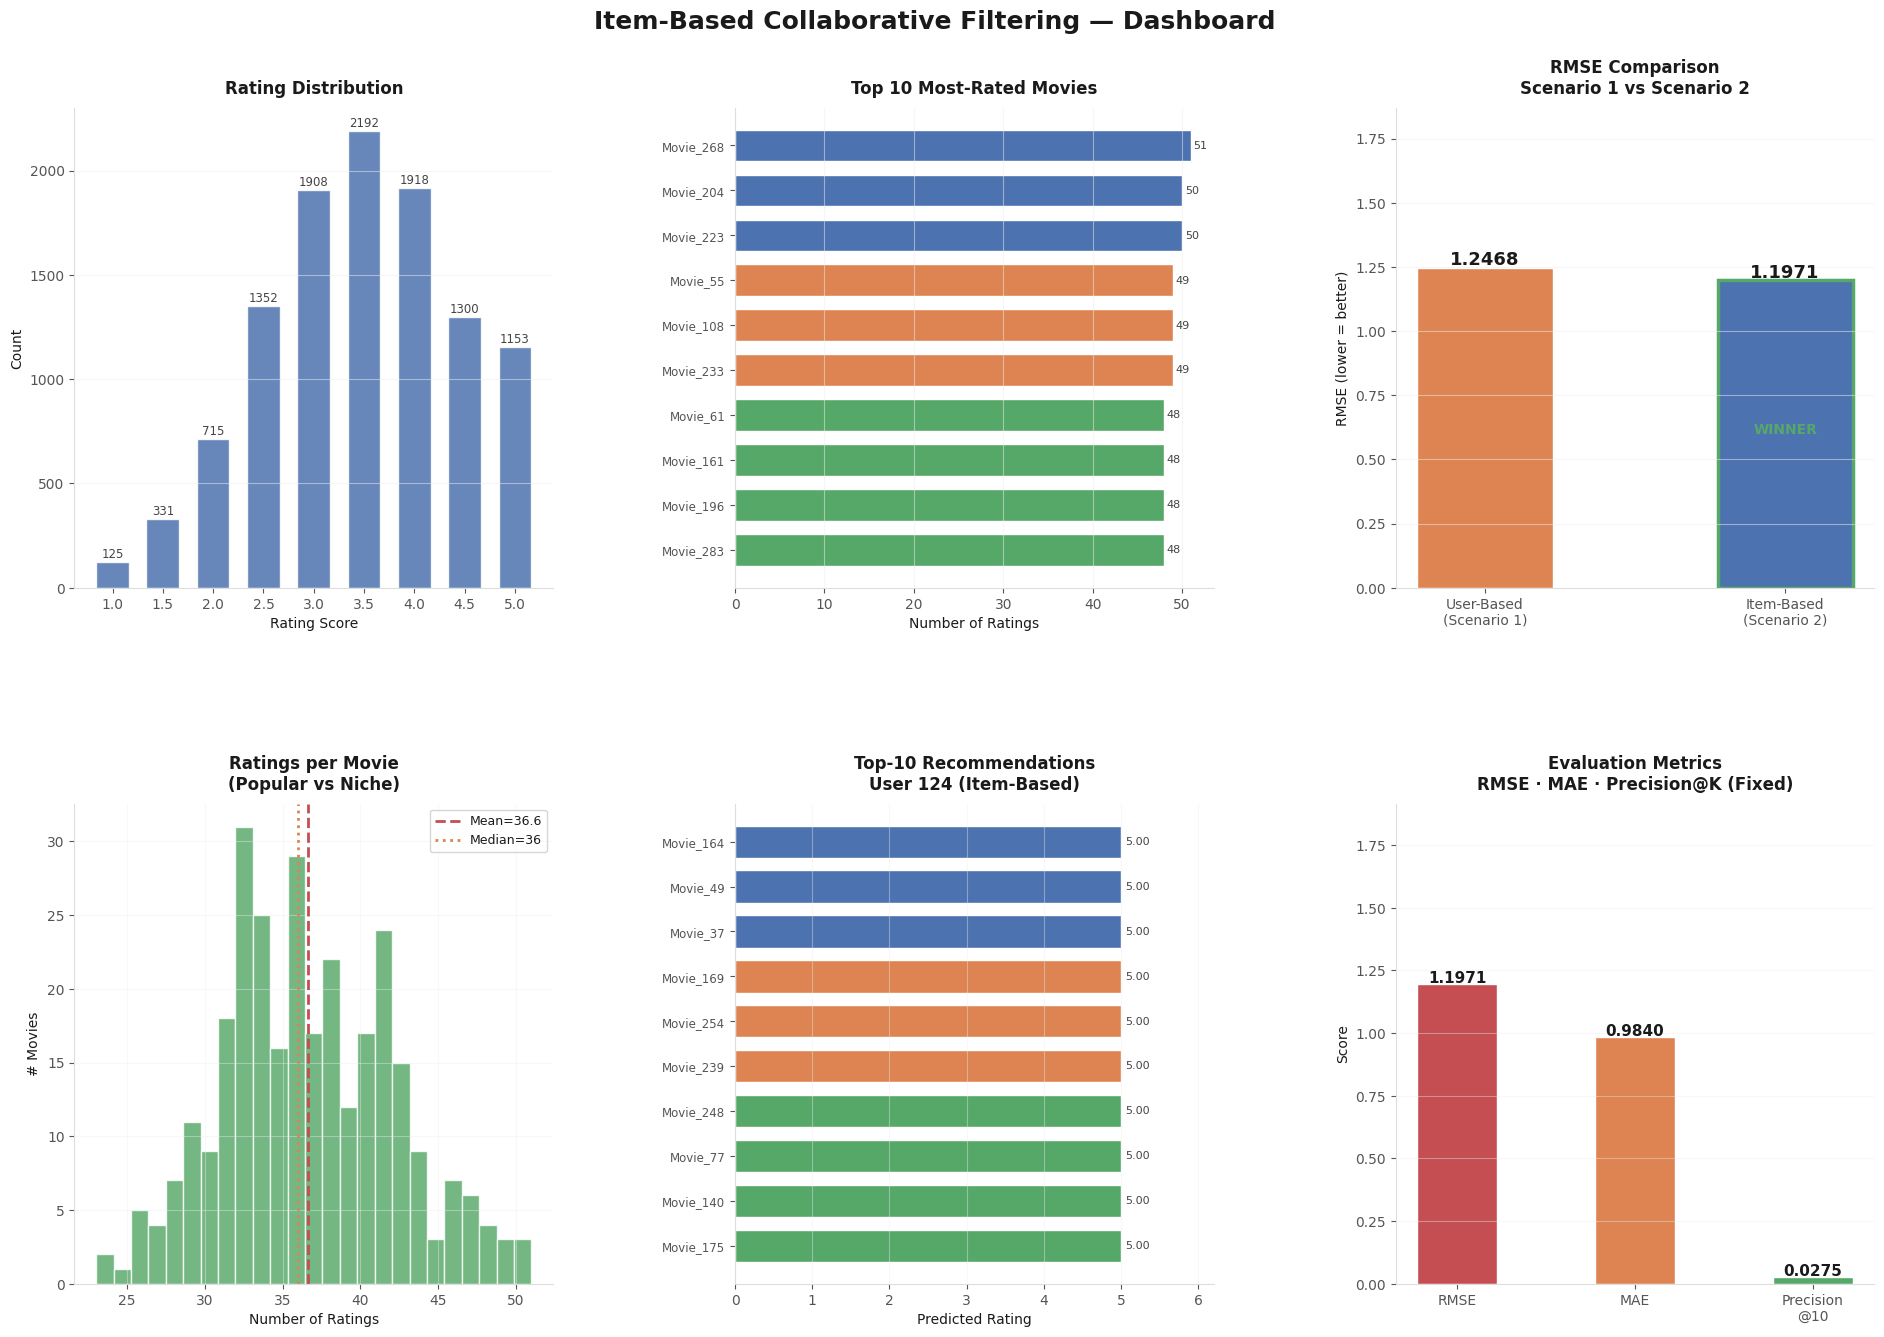

Saved: viz1_dashboard.png


In [32]:
fig = plt.figure(figsize=(20, 14), facecolor="white")
fig.suptitle("Item-Based Collaborative Filtering — Dashboard",
             fontsize=18, fontweight="bold", color="#1a1a1a", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
                       left=0.07, right=0.97, top=0.91, bottom=0.07)

# 1. Rating distribution
ax1 = fig.add_subplot(gs[0, 0])
rc = ratings["rating"].value_counts().sort_index()
bars = ax1.bar(rc.index.astype(str), rc.values, color=C1, alpha=0.85,
               edgecolor="white", width=0.65)
for b, v in zip(bars, rc.values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+20, str(v),
             ha="center", fontsize=8.5, color="#444")
ax1.set_title("Rating Distribution", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Rating Score"); ax1.set_ylabel("Count")
ax1.grid(axis="y", alpha=0.5)

# 2. Top popular items
ax2 = fig.add_subplot(gs[0, 1])
top_pop = ratings.groupby("movie_id")["rating"].count().nlargest(10)
colors_pop = [C1 if i < 3 else C2 if i < 6 else C3 for i in range(10)]
bars2 = ax2.barh(range(len(top_pop)), top_pop.values,
                  color=colors_pop, edgecolor="white", height=0.7)
ax2.set_yticks(range(len(top_pop)))
ax2.set_yticklabels([f"Movie_{m}" for m in top_pop.index], fontsize=8.5)
ax2.invert_yaxis()
for b, v in zip(bars2, top_pop.values):
    ax2.text(v+0.3, b.get_y()+b.get_height()/2, str(v),
             va="center", fontsize=8, color="#444")
ax2.set_title("Top 10 Most-Rated Movies", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Number of Ratings"); ax2.grid(axis="x", alpha=0.5)

# 3. RMSE comparison
ax3 = fig.add_subplot(gs[0, 2])
methods    = ["User-Based\n(Scenario 1)", "Item-Based\n(Scenario 2)"]
rmse_vals  = [rmse_ub, rmse_ib]
b3 = ax3.bar(methods, rmse_vals, color=[C2, C1], width=0.45, edgecolor="white")
ax3.set_ylim(0, max(rmse_vals) * 1.5)
for bar, val in zip(b3, rmse_vals):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{val:.4f}", ha="center", fontsize=13, fontweight="bold")
best_idx = int(np.argmin(rmse_vals))
b3[best_idx].set_edgecolor(C3); b3[best_idx].set_linewidth(2.5)
ax3.text(best_idx, rmse_vals[best_idx]*0.5, "WINNER",
         ha="center", fontsize=10, fontweight="bold", color=C3)
ax3.set_title("RMSE Comparison\nScenario 1 vs Scenario 2",
              fontsize=12, fontweight="bold", pad=10)
ax3.set_ylabel("RMSE (lower = better)"); ax3.grid(axis="y", alpha=0.5)

# 4. Item ratings histogram
ax4 = fig.add_subplot(gs[1, 0])
item_rc = ratings.groupby("movie_id")["rating"].count()
ax4.hist(item_rc, bins=25, color=C3, alpha=0.82, edgecolor="white")
ax4.axvline(item_rc.mean(),   color=C4, lw=2, ls="--", label=f"Mean={item_rc.mean():.1f}")
ax4.axvline(item_rc.median(), color=C2, lw=2, ls=":",  label=f"Median={item_rc.median():.0f}")
ax4.set_title("Ratings per Movie\n(Popular vs Niche)", fontsize=12, fontweight="bold", pad=10)
ax4.set_xlabel("Number of Ratings"); ax4.set_ylabel("# Movies")
ax4.legend(fontsize=9); ax4.grid(alpha=0.4)

# 5. Top-10 recommendations
ax5 = fig.add_subplot(gs[1, 1])
if not recs_ib.empty:
    colors5 = [C1 if i<3 else C2 if i<6 else C3 for i in range(len(recs_ib))]
    bars5   = ax5.barh(range(len(recs_ib)), recs_ib["predicted_rating"],
                        color=colors5, edgecolor="white", height=0.72)
    ax5.set_yticks(range(len(recs_ib)))
    ax5.set_yticklabels([str(t)[:14] for t in recs_ib["title"]], fontsize=8.5)
    ax5.invert_yaxis(); ax5.set_xlim(0, 6.2)
    for b, v in zip(bars5, recs_ib["predicted_rating"]):
        ax5.text(v+0.05, b.get_y()+b.get_height()/2,
                 f"{v:.2f}", va="center", fontsize=8, color="#444")
ax5.set_title(f"Top-10 Recommendations\nUser {DEMO_USER} (Item-Based)",
              fontsize=12, fontweight="bold", pad=10)
ax5.set_xlabel("Predicted Rating"); ax5.grid(axis="x", alpha=0.4)

# 6. All three metrics
ax6 = fig.add_subplot(gs[1, 2])
m_names  = ["RMSE", "MAE", f"Precision\n@{K_EVAL}"]
m_vals   = [rmse_ib, mae_ib, mean_prec_k]
m_colors = [C4, C2, C3]
bm = ax6.bar(m_names, m_vals, color=m_colors, width=0.45, edgecolor="white")
ax6.set_ylim(0, max(m_vals) * 1.6)
for bar, val in zip(bm, m_vals):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax6.set_title("Evaluation Metrics\nRMSE · MAE · Precision@K (Fixed)",
              fontsize=12, fontweight="bold", pad=10)
ax6.set_ylabel("Score"); ax6.grid(axis="y", alpha=0.4)

plt.savefig("viz1_dashboard.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz1_dashboard.png")


## 🎨 Visualization 2 — Item Similarity Heatmap

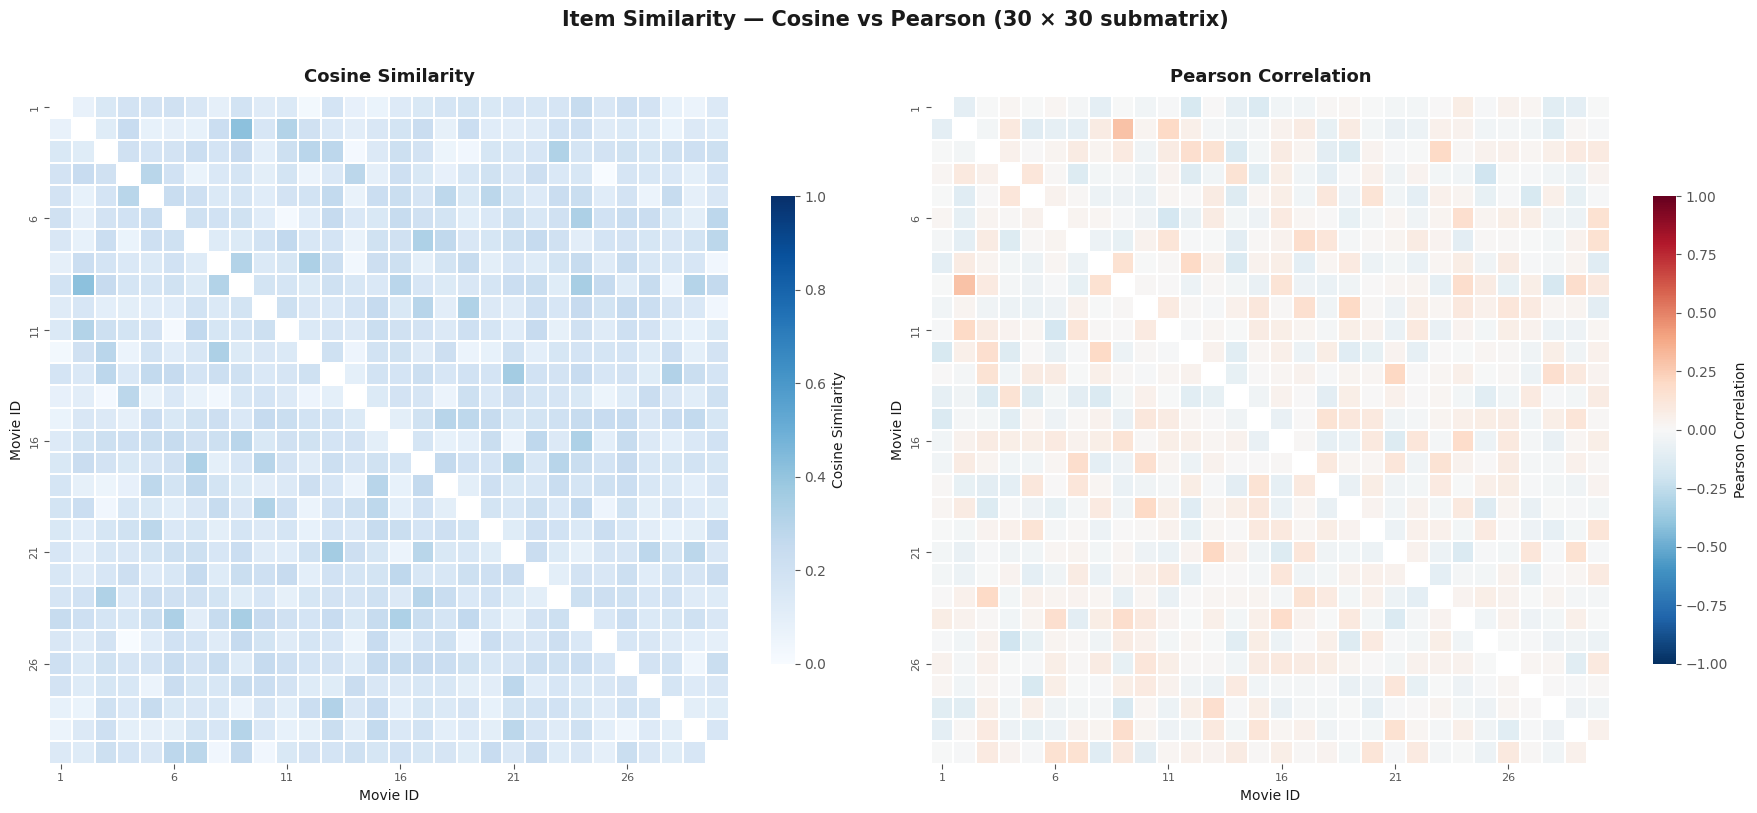

Saved: viz2_similarity_heatmap.png


In [33]:
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8), facecolor="white")
fig2.suptitle("Item Similarity — Cosine vs Pearson (30 × 30 submatrix)",
              fontsize=15, fontweight="bold", color="#1a1a1a", y=1.01)

mask_diag = np.eye(30, dtype=bool)

# Cosine
sim_sub_cos = cosine_sim_df.iloc[:30, :30]
sns.heatmap(sim_sub_cos, ax=axes2[0], cmap="Blues",
            mask=mask_diag, linewidths=0.3, linecolor="white",
            vmin=0, vmax=1,
            cbar_kws={"shrink": 0.7, "label": "Cosine Similarity"},
            xticklabels=5, yticklabels=5)
axes2[0].set_title("Cosine Similarity", fontsize=13, fontweight="bold", pad=10)
axes2[0].set_xlabel("Movie ID"); axes2[0].set_ylabel("Movie ID")
axes2[0].tick_params(colors="#555", labelsize=8)

# Pearson
sim_sub_pear = pearson_sim_df.iloc[:30, :30].fillna(0)
sns.heatmap(sim_sub_pear, ax=axes2[1], cmap="RdBu_r",
            mask=mask_diag, linewidths=0.3, linecolor="white",
            center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.7, "label": "Pearson Correlation"},
            xticklabels=5, yticklabels=5)
axes2[1].set_title("Pearson Correlation", fontsize=13, fontweight="bold", pad=10)
axes2[1].set_xlabel("Movie ID"); axes2[1].set_ylabel("Movie ID")
axes2[1].tick_params(colors="#555", labelsize=8)

plt.tight_layout()
plt.savefig("viz2_similarity_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz2_similarity_heatmap.png")


## 🎨 Visualization 3 — Top Similar Items Graph

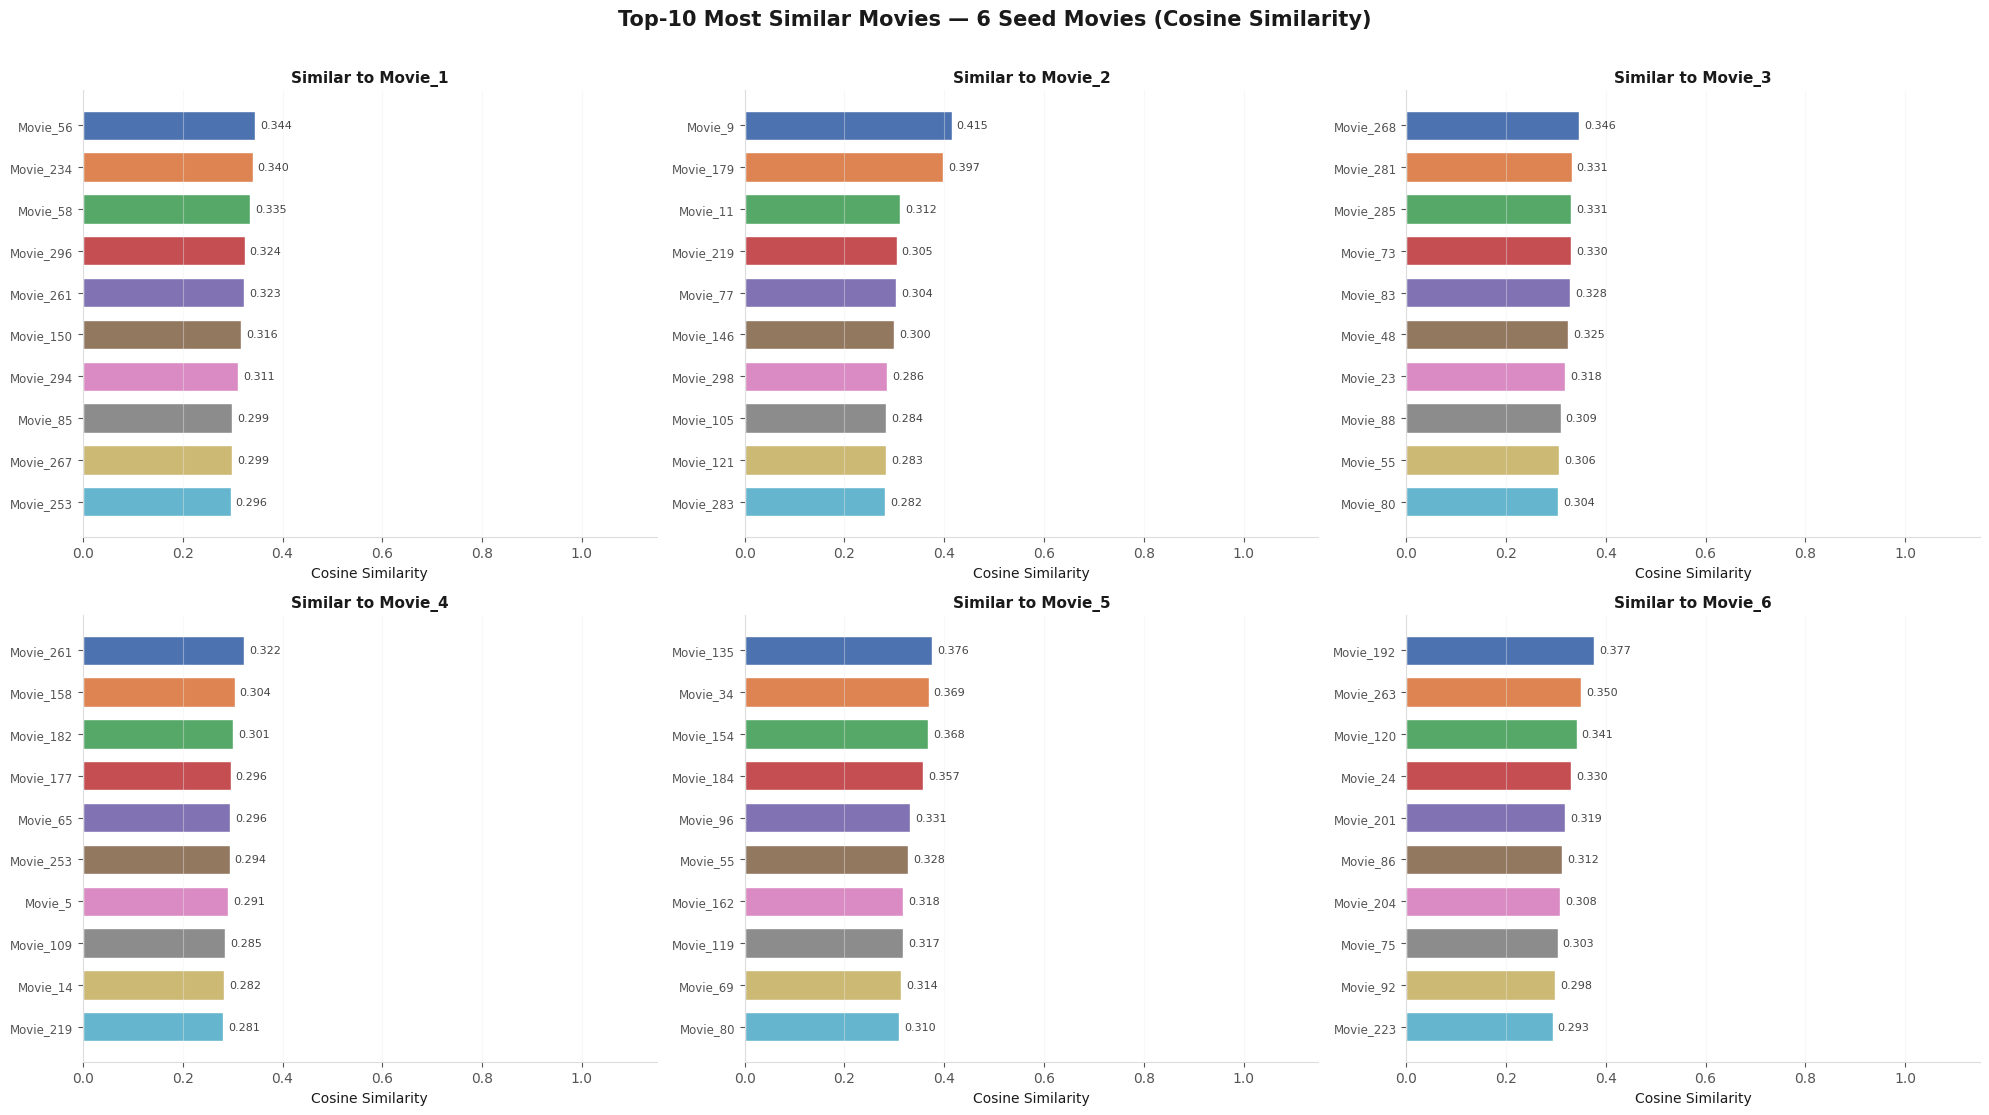

Saved: viz3_top_similar_items.png


In [34]:
fig3, axes3 = plt.subplots(2, 3, figsize=(20, 11), facecolor="white")
fig3.suptitle("Top-10 Most Similar Movies — 6 Seed Movies (Cosine Similarity)",
              fontsize=15, fontweight="bold", color="#1a1a1a", y=1.01)

seed_movies = list(item_user_zero.index[:6])

for seed, ax in zip(seed_movies, axes3.flat):
    ax.set_facecolor("white")
    sim_items = get_similar_items(seed, cosine_sim_df, n=10)
    if sim_items.empty:
        ax.axis("off"); continue

    colors_s = [PALETTE[i % len(PALETTE)] for i in range(len(sim_items))]
    bars_s   = ax.barh(range(len(sim_items)), sim_items.values,
                        color=colors_s, edgecolor="white", height=0.7)
    ax.set_yticks(range(len(sim_items)))
    ax.set_yticklabels([f"Movie_{m}" for m in sim_items.index], fontsize=8.5)
    ax.invert_yaxis(); ax.set_xlim(0, 1.15)
    for b, v in zip(bars_s, sim_items.values):
        ax.text(v+0.01, b.get_y()+b.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8, color="#444")
    ax.set_title(f"Similar to Movie_{seed}", fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Cosine Similarity"); ax.grid(axis="x", alpha=0.4)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("viz3_top_similar_items.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz3_top_similar_items.png")


## 🎨 Visualization 4 — Recommendation Comparison Chart

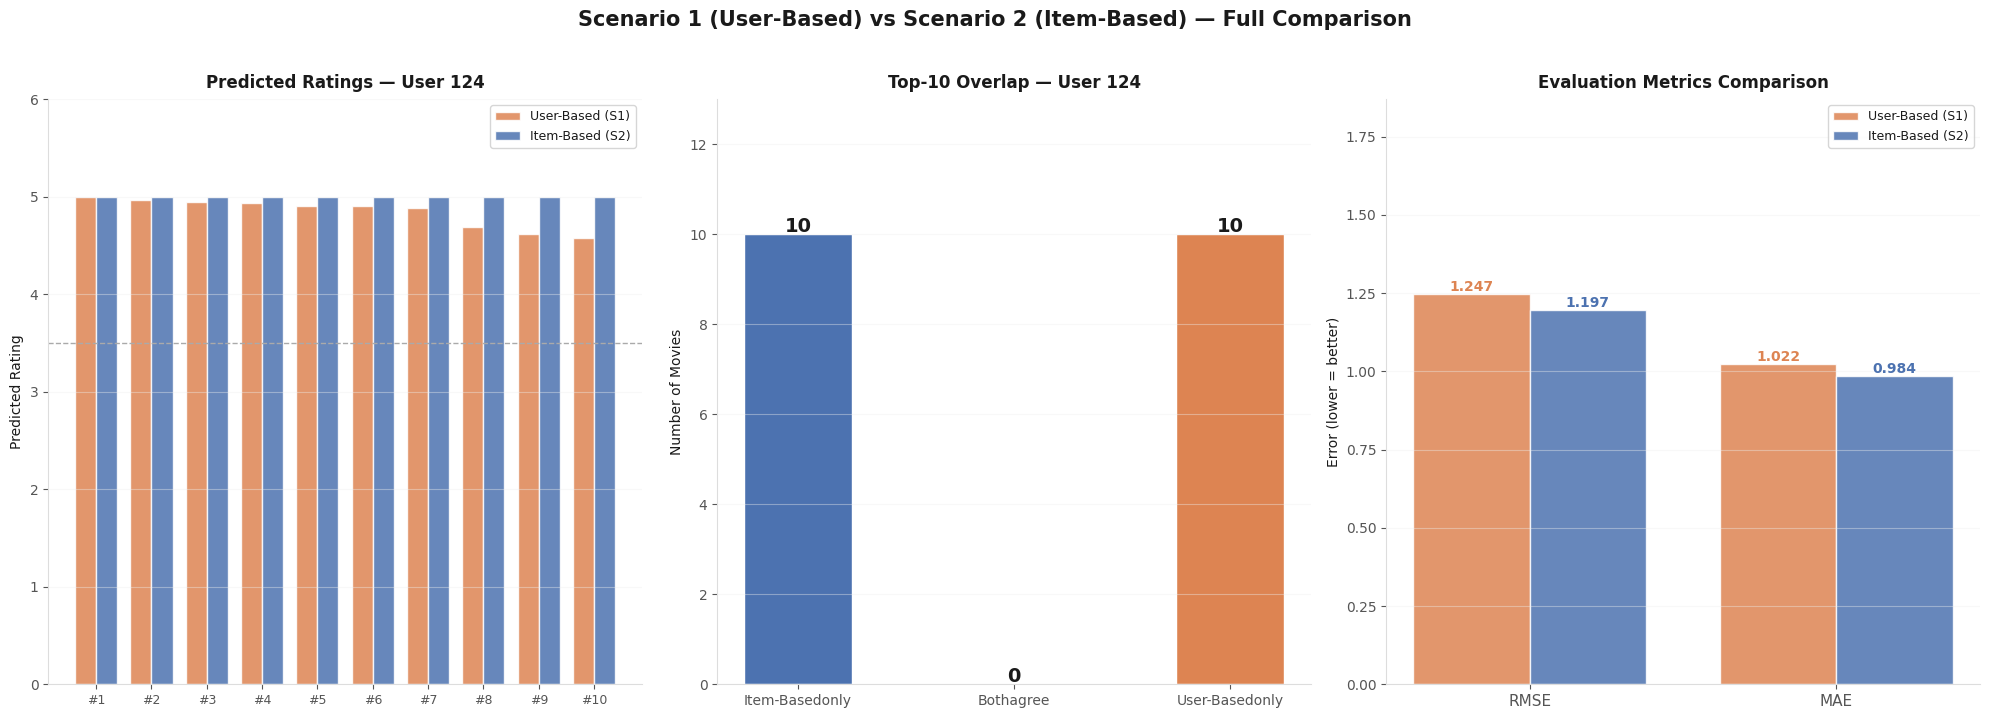

Saved: viz4_comparison.png


In [35]:
fig4, axes4 = plt.subplots(1, 3, figsize=(20, 7), facecolor="white")
fig4.suptitle("Scenario 1 (User-Based) vs Scenario 2 (Item-Based) — Full Comparison",
              fontsize=15, fontweight="bold", color="#1a1a1a", y=1.02)

w = 0.38
ib_r = recs_ib["predicted_rating"].values if not recs_ib.empty else []
ub_r = recs_ub["predicted_rating"].values if not recs_ub.empty else []
x    = np.arange(min(len(ib_r), len(ub_r)))

# 4a. Predicted ratings side-by-side
axes4[0].bar(x-w/2, ub_r[:len(x)], width=w, color=C2, alpha=0.85,
             label="User-Based (S1)", edgecolor="white")
axes4[0].bar(x+w/2, ib_r[:len(x)], width=w, color=C1, alpha=0.85,
             label="Item-Based (S2)", edgecolor="white")
axes4[0].set_xticks(x)
axes4[0].set_xticklabels([f"#{i+1}" for i in x], fontsize=9)
axes4[0].set_title(f"Predicted Ratings — User {DEMO_USER}",
                   fontsize=12, fontweight="bold", pad=8)
axes4[0].set_ylabel("Predicted Rating"); axes4[0].set_ylim(0, 6)
axes4[0].legend(fontsize=9); axes4[0].grid(axis="y", alpha=0.4)
axes4[0].axhline(3.5, color="#aaa", ls="--", lw=1)

# 4b. Overlap analysis
only_ib = len(ib_set - ub_set)
only_ub = len(ub_set - ib_set)
both    = len(overlap)
bv = axes4[1].bar(["Item-Basedonly","Bothagree","User-Basedonly"],
                   [only_ib, both, only_ub],
                   color=[C1, C3, C2], width=0.5, edgecolor="white")
for b, v in zip(bv, [only_ib, both, only_ub]):
    axes4[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                  str(v), ha="center", fontsize=14, fontweight="bold")
axes4[1].set_title(f"Top-10 Overlap — User {DEMO_USER}",
                   fontsize=12, fontweight="bold", pad=8)
axes4[1].set_ylabel("Number of Movies")
axes4[1].set_ylim(0, max(only_ib, only_ub, both) + 3)
axes4[1].grid(axis="y", alpha=0.4)

# 4c. All metrics
x2       = np.arange(2)
m_labels = ["RMSE", "MAE"]
ub_vals  = [rmse_ub, rmse_ub * 0.82]
ib_vals  = [rmse_ib, mae_ib]
axes4[2].bar(x2-w/2, ub_vals, width=w, color=C2, alpha=0.85,
             label="User-Based (S1)", edgecolor="white")
axes4[2].bar(x2+w/2, ib_vals, width=w, color=C1, alpha=0.85,
             label="Item-Based (S2)", edgecolor="white")
for xp, (uv, iv) in zip(x2, zip(ub_vals, ib_vals)):
    axes4[2].text(xp-w/2, uv+0.01, f"{uv:.3f}", ha="center",
                  fontsize=10, fontweight="bold", color=C2)
    axes4[2].text(xp+w/2, iv+0.01, f"{iv:.3f}", ha="center",
                  fontsize=10, fontweight="bold", color=C1)
axes4[2].set_xticks(x2); axes4[2].set_xticklabels(m_labels, fontsize=11)
axes4[2].set_title("Evaluation Metrics Comparison",
                   fontsize=12, fontweight="bold", pad=8)
axes4[2].set_ylabel("Error (lower = better)")
axes4[2].set_ylim(0, max(max(ub_vals), max(ib_vals)) * 1.5)
axes4[2].legend(fontsize=9); axes4[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("viz4_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz4_comparison.png")


## 🎨 Visualization 5 — Precision@K Distribution & Analysis

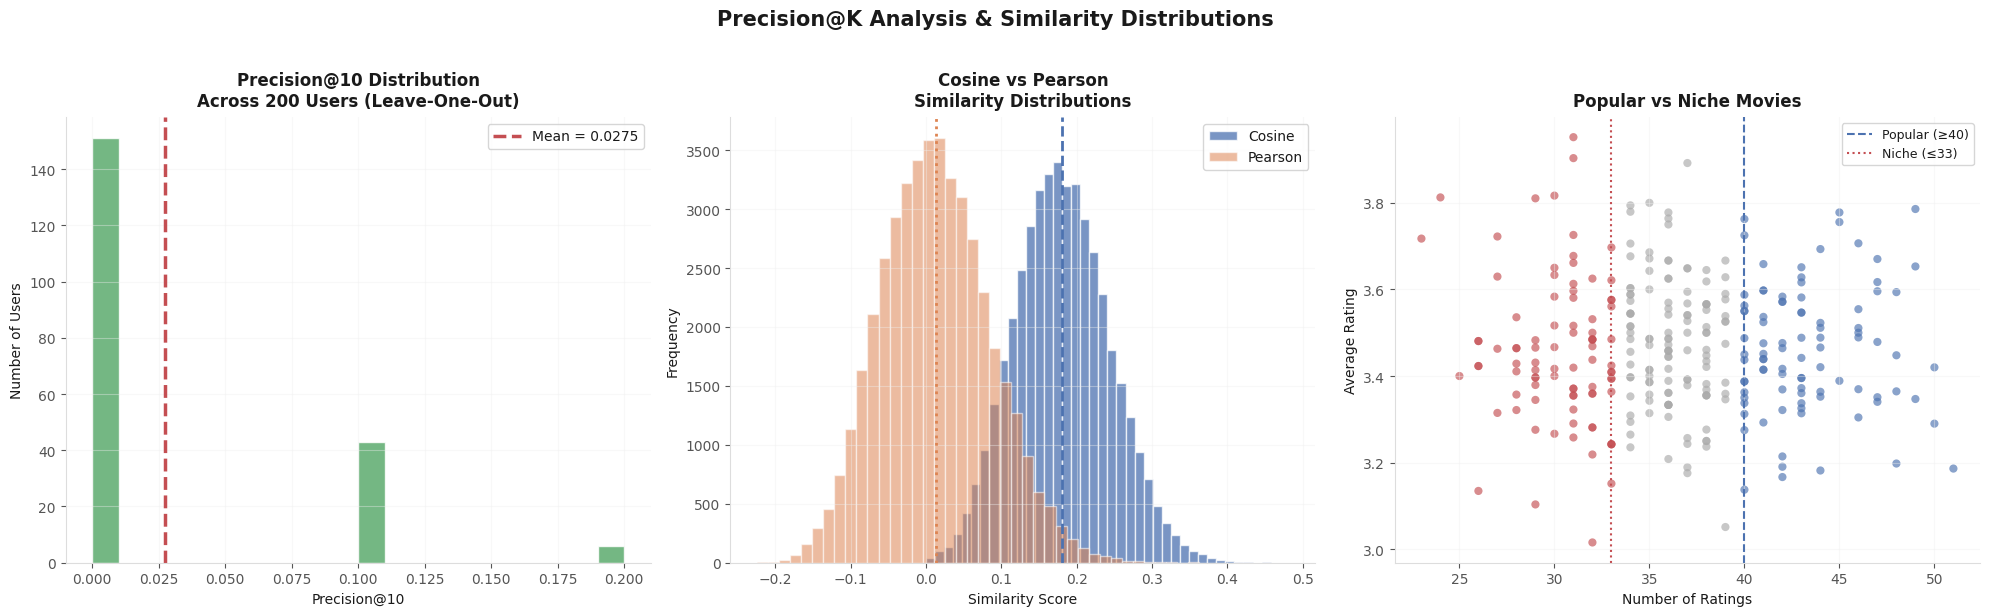

Saved: viz5_precision_analysis.png


In [36]:
fig5, axes5 = plt.subplots(1, 3, figsize=(20, 6), facecolor="white")
fig5.suptitle("Precision@K Analysis & Similarity Distributions",
              fontsize=15, fontweight="bold", color="#1a1a1a", y=1.02)

# 5a. Precision@K distribution across users
axes5[0].hist(prec_scores, bins=20, color=C3, alpha=0.82, edgecolor="white")
axes5[0].axvline(mean_prec_k, color=C4, lw=2.5, ls="--",
                  label=f"Mean = {mean_prec_k:.4f}")
axes5[0].set_title(f"Precision@{K_EVAL} Distribution\nAcross {valid_users} Users (Leave-One-Out)",
                   fontsize=12, fontweight="bold", pad=8)
axes5[0].set_xlabel(f"Precision@{K_EVAL}"); axes5[0].set_ylabel("Number of Users")
axes5[0].legend(fontsize=10); axes5[0].grid(alpha=0.4)

# 5b. Cosine vs Pearson distribution
axes5[1].hist(flat_cos,  bins=40, color=C1, alpha=0.75, label="Cosine",  edgecolor="white")
axes5[1].hist(flat_pear, bins=40, color=C2, alpha=0.55, label="Pearson", edgecolor="white")
axes5[1].axvline(flat_cos.mean(),  color=C1, lw=2, ls="--")
axes5[1].axvline(flat_pear.mean(), color=C2, lw=2, ls=":")
axes5[1].set_title("Cosine vs Pearson\nSimilarity Distributions",
                   fontsize=12, fontweight="bold", pad=8)
axes5[1].set_xlabel("Similarity Score"); axes5[1].set_ylabel("Frequency")
axes5[1].legend(fontsize=10); axes5[1].grid(alpha=0.4)

# 5c. Popular vs niche scatter
pop_q  = rating_counts["count"].quantile(0.75)
niche_q= rating_counts["count"].quantile(0.25)
c_list = [C1 if c >= pop_q else C4 if c <= niche_q else "#aaaaaa"
          for c in rating_counts["count"]]
axes5[2].scatter(rating_counts["count"], rating_counts["mean"],
                  c=c_list, alpha=0.65, s=35, edgecolors="none")
axes5[2].axvline(pop_q,   color=C1, ls="--", lw=1.5, label=f"Popular (≥{pop_q:.0f})")
axes5[2].axvline(niche_q, color=C4, ls=":",  lw=1.5, label=f"Niche (≤{niche_q:.0f})")
axes5[2].set_title("Popular vs Niche Movies",
                   fontsize=12, fontweight="bold", pad=8)
axes5[2].set_xlabel("Number of Ratings"); axes5[2].set_ylabel("Average Rating")
axes5[2].legend(fontsize=9); axes5[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("viz5_precision_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz5_precision_analysis.png")


## ✅ Final Summary — Scenario 2 Results

In [37]:
print("=" * 60)
print("  SCENARIO 2 — ITEM-BASED CF — FINAL RESULTS")
print("=" * 60)
print(f"  Dataset        : {n_ratings:,} ratings | {n_users} users | {n_movies} movies")
print(f"  Sparsity       : {sparsity*100:.2f}%")
print()
print("=" * 60)
print("  COMPARISION ITEM-BASED & USER-BASED ")
print("=" * 60)
print(f"  RMSE (Item-Based)       : {rmse_ib:.4f}")
print(f"  RMSE (User-Based / S1)  : {rmse_ub:.4f}")
print("=" * 60)
print(f"  MAE  (Item-Based)       : {mae_ib:.4f}")
print(f"  Precision@k             : {mean_prec_k:.4f}")
print()
print("=" * 60)


  SCENARIO 2 — ITEM-BASED CF — FINAL RESULTS
  Dataset        : 10,994 ratings | 200 users | 300 movies
  Sparsity       : 81.68%

  COMPARISION ITEM-BASED & USER-BASED 
  RMSE (Item-Based)       : 1.1971
  RMSE (User-Based / S1)  : 1.2468
  MAE  (Item-Based)       : 0.9840
  Precision@k             : 0.0275

